# Adam (Adaptive Momentum)

Adam is built atop RMSProp, with the momentum concept from SGD added back in. This means that, instead of applying current gradients, we’re going to apply momentums like in the SGD optimizer with momentum, then apply a per-weight adaptive learning rate with the cache as done in RMSProp. 

## Recall Learning Rate Decay
$$
\underbrace{\alpha_t}_{\text{current learning rate}} = \frac{\underbrace{\alpha_0}_{\text{initial lr}}}{1 + \underbrace{\text{decay} \cdot t}_{\text{iteration decay}}}
$$

## First Moment (Momentum)
$$
\underbrace{m_t}_{\text{1st moment}} = \underbrace{\beta_1 \cdot m_{t-1}}_{\text{exponential moving average of gradients}} + \underbrace{(1-\beta_1)g_t}_{\text{loss gradient}}
$$

## Bias-Corrected First Moment
### Code
```python
self.momentum_corrected = self.momentum / (1. - self.beta_1**self.iterations)
```
$$
\hat{m}_t = \frac{m_t}{1 - \beta_1^t}
$$
#### Why this exists

- At early steps $m_t$ is biased toward 0
- This correction negates it so the true mean

## Second Moment (RMSProp-style cache)
### Code
```python
self.weightSquaredCache = self.beta_2 * self.weightSquaredCache + \
    (1. - self.beta_2) * self.gradients**2
```
$$
\underbrace{v_t}_{\text{2nd moment}} = \underbrace{\beta_2 \cdot v_{t-1}}_{\text{previous}} + \underbrace{(1-\beta_2)g_t^2}_{\text{new squared gradients}}
$$

- This tracks magnitude inside of gradients
- Same idea as RMSProp

## Bias-Corrected Second Moment
### Code
```python
weightSquaredCache_corrected = self.weightSquaredCache / \
    (1. - self.beta_2**self.iterations)
```
$$
\hat{v}_t = \frac{v_t}{1-\beta_2^t}
$$
- Same bias issue = same fix

## Final Parameter Update
### Code

```python
layer.weights -= self.learning_rate * \
    self.momentum_corrected / \
    (np.sqrt(self.weightSquaredCache_corrected) + self.epsilon)
```
$$
\underbrace{\theta_t}_{\text{new weights}} = \underbrace{\theta_{t-1}}_{\text{old weights}} - \underbrace{\alpha_t}_{\text{learning rate}} \cdot \frac{\underbrace{\hat{m}_t}_{\text{momentum}}}{\underbrace{\sqrt{\hat{v}_t} + \epsilon}_{\text{RMS scaling}}}
$$


In [1]:
# imports
import matplotlib.pyplot as plt
import numpy as np 
import math
import nnfs

from nnfs.datasets import spiral_data

# Implementation of `Optimizer_Adam`

In [ ]:
class Optimizer_Adam: 
    # initialize optimizer - set settings 
    def __init__(self, learning_rate=0.001, decay=0., epsilon=1e-7, beta_1=0.9, beta_2=0.999): 
        self.learning_rate = learning_rate 
        self.current_learning_rate = learning_rate 
        self.decay = decay 
        self.iterations = 0 
        self.epsilon = epsilon 
        self.beta_1 = beta_1 
        self.beta_2 = beta_2 
 
    # call once before any parameter updates 
    def pre_update_params(self): 
        if self.decay: 
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations)) 
 
    # update parameters 
    def update_params(self, layer): 
 
        # if layer does not contain cache arrays, 
        # create them filled with zeros 
        if not hasattr(layer, 'weight_cache'): 
            layer.weight_momentums = np.zeros_like(layer.weights) 
            layer.weight_cache = np.zeros_like(layer.weights) 
            layer.bias_momentums = np.zeros_like(layer.biases) 
            layer.bias_cache = np.zeros_like(layer.biases) 
 
        # update momentum  with current gradients
        # beta_1 acting as momentum (beta_1 = momentum)
        # beta so that most recent gradients are used
        # and older ones are being exponentially decayed
        # (1 - beta) shows how much the current gradient
        # contributes
        layer.weight_momentums = self.beta_1 * layer.weight_momentums + (1 - self.beta_1) * layer.dweights 
        layer.bias_momentums = self.beta_1 * layer.bias_momentums + (1 - self.beta_1) * layer.dbiases 
        # get corrected momentum 
        # self.iteration is 0 at first pass 
        # and we need to start with 1 here 
        weight_momentums_corrected = layer.weight_momentums / (1 - self.beta_1 ** (self.iterations + 1)) 
        bias_momentums_corrected = layer.bias_momentums / (1 - self.beta_1 ** (self.iterations + 1)) 
        # update cache with squared current gradients (rmsprop style)
        # beta_2 acting as rho
        layer.weight_cache = self.beta_2 * layer.weight_cache + (1 - self.beta_2) * layer.dweights**2 
        layer.bias_cache = self.beta_2 * layer.bias_cache + (1 - self.beta_2) * layer.dbiases**2 
        # get corrected cache 
        weight_cache_corrected = layer.weight_cache / (1 - self.beta_2 ** (self.iterations + 1)) 
        bias_cache_corrected = layer.bias_cache / (1 - self.beta_2 ** (self.iterations + 1)) 
 
        # vanilla sgd parameter update + normalization 
        # with square rooted cache 
        layer.weights += -self.current_learning_rate * weight_momentums_corrected / (np.sqrt(weight_cache_corrected) + self.epsilon) 
        layer.biases += -self.current_learning_rate * bias_momentums_corrected / (np.sqrt(bias_cache_corrected) + self.epsilon) 
 
    # call once after any parameter updates 
    def post_update_params(self): 
        self.iterations += 1 

# Initialize Dense, ReLU, Loss

In [ ]:
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

    def forward(self, inputs):
        self.inputs = inputs 
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        self.dinputs = np.dot(dvalues, self.weights.T)

class Activation_ReLU: 
    def forward(self, inputs): 
        self.inputs = inputs 
        self.output = np.maximum(0, inputs) 

    def backward(self, dvalues): 
        self.dinputs = dvalues.copy() 
        self.dinputs[self.inputs <= 0] = 0 

class Loss: 
    def calculate(self, output, y): 
        sample_losses = self.forward(output, y) 
        data_loss = np.mean(sample_losses) 
        return data_loss 
 
class Loss_CategoricalCrossentropy(Loss): 
    def forward(self, y_pred, y_true): 
        samples = len(y_pred) 
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7) 
        if len(y_true.shape) == 1: 
            correct_confidences = y_pred_clipped[ 
                range(samples), 
                y_true 
            ] 
        elif len(y_true.shape) == 2: 
            correct_confidences = np.sum( 
                y_pred_clipped * y_true, 
                axis=1 
            ) 
 
        negative_log_likelihoods = -np.log(correct_confidences) 
        return negative_log_likelihoods 
 
    def backward(self, dvalues, y_true): 
        samples = len(dvalues) 
        labels = len(dvalues[0]) 

        if len(y_true.shape) == 1: 
            y_true = np.eye(labels)[y_true] 
 
        self.dinputs = -y_true / dvalues 
        self.dinputs = self.dinputs / samples 

class Activation_Softmax: 
    def forward(self, inputs): 
        self.inputs = inputs 
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True)) 
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True) 
        self.output = probabilities 

    def backward(self, dvalues): 
        self.dinputs = np.empty_like(dvalues) 
 
        for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)): 
            single_output = single_output.reshape(-1, 1) 
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T) 

            self.dinputs[index] = np.dot(jacobian_matrix, 
                                         single_dvalues) 
 
class Activation_Softmax_Loss_CategoricalCrossentropy(): 
    def __init__(self): 
        self.activation = Activation_Softmax() 
        self.loss = Loss_CategoricalCrossentropy() 
 
    def forward(self, inputs, y_true): 
        self.activation.forward(inputs) 
        self.output = self.activation.output 
        return self.loss.calculate(self.output, y_true) 
 
    def backward(self, dvalues, y_true): 
 
        samples = len(dvalues) 
 
        if len(y_true.shape) == 2: 
            y_true = np.argmax(y_true, axis=1) 
 
        self.dinputs = dvalues.copy() 
        self.dinputs[range(samples), y_true] -= 1 
        self.dinputs = self.dinputs / samples 

# Train

In [ ]:
X, y_true = spiral_data(samples=200, classes=3)

learning_rate = 0.02
decay = 1e-5
epochs = 10_000
rho = 0.4

# re-initialize fresh weights
dense1_layer = Layer_Dense(2, 64)
relu_activation = Activation_ReLU()
output_layer = Layer_Dense(64, 3)
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()
optimizer = Optimizer_Adam(learning_rate=learning_rate, decay=decay, beta_1=rho) # optimizer

loss_history, accuracy_history, learning_rate_history = [], [], []

for epoch in range(epochs):
    # forward
    dense1_layer.forward(X)
    relu_activation.forward(dense1_layer.output)
    output_layer.forward(relu_activation.output)
    loss = loss_activation.forward(output_layer.output, y_true)

    predictions = np.argmax(loss_activation.output, axis=1)
    if len(y_true.shape) == 2:
        y_labels = np.argmax(y_true, axis=1)
    else:
        y_labels = y_true
    accuracy = np.mean(predictions == y_labels)

    # backward
    loss_activation.backward(loss_activation.output, y_true)
    output_layer.backward(loss_activation.dinputs)
    relu_activation.backward(output_layer.dinputs)
    dense1_layer.backward(relu_activation.dinputs)

    # Update weights
    # stochastic gradient optimizer
    optimizer.pre_update_params() 
    optimizer.update_params(dense1_layer) 
    optimizer.update_params(output_layer) 
    optimizer.post_update_params()

    if epoch % (epochs // 10) == 0:
        print(f"epoch: {epoch:>4} accuracy: {accuracy:>4} loss: {loss:.4f}")
    
    loss_history.append(loss)
    accuracy_history.append(accuracy)
    learning_rate_history.append(optimizer.current_learning_rate)



epoch:    0 accuracy: 0.335 loss: 1.0976
epoch: 1000 accuracy: 0.9016666666666666 loss: 0.2240
epoch: 2000 accuracy: 0.9266666666666666 loss: 0.1814
epoch: 3000 accuracy: 0.935 loss: 0.1622
epoch: 4000 accuracy: 0.935 loss: 0.1479
epoch: 5000 accuracy: 0.9366666666666666 loss: 0.1407
epoch: 6000 accuracy: 0.94 loss: 0.1358
epoch: 7000 accuracy: 0.94 loss: 0.1313
epoch: 8000 accuracy: 0.9416666666666667 loss: 0.1272
epoch: 9000 accuracy: 0.9416666666666667 loss: 0.1241


# Initialize Fitted Line Graph Function

In [10]:
def plot_decision_boundary(model_layers, X, y, resolution=0.02):
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, resolution),
        np.arange(y_min, y_max, resolution)
    )
    
    # Flatten mesh and predict
    Z_input = np.c_[xx.ravel(), yy.ravel()]
    
    # Forward pass through network
    dense1_layer.forward(Z_input)
    relu_activation.forward(dense1_layer.output)
    output_layer.forward(relu_activation.output)
    loss_activation.forward(output_layer.output, np.zeros((len(Z_input), 3)))
    
    # Get predictions
    Z = np.argmax(loss_activation.output, axis=1).reshape(xx.shape)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Contourf for decision boundaries
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis', levels=2)
    
    # Scatter plot for actual data
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y if len(y.shape) == 1 else np.argmax(y, axis=1),
                        cmap='viridis', edgecolors='k', s=50, alpha=0.7)
    
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title('Neural Network Decision Boundaries')
    plt.colorbar(scatter, ax=ax, label='Class')
    plt.tight_layout()
    plt.show()

# Visualize Evaluations

Final Values: Loss 0.12104713160441821 Accuracy 0.9433333333333334 Learning Rate 0.018181983472577025
Learning Rate 0.02 Decay 1e-05


C:\Users\paolo\AppData\Local\Temp\ipykernel_7984\881293027.py:45: RuntimeWarning: divide by zero encountered in log
  negative_log_likelihoods = -np.log(correct_confidences)


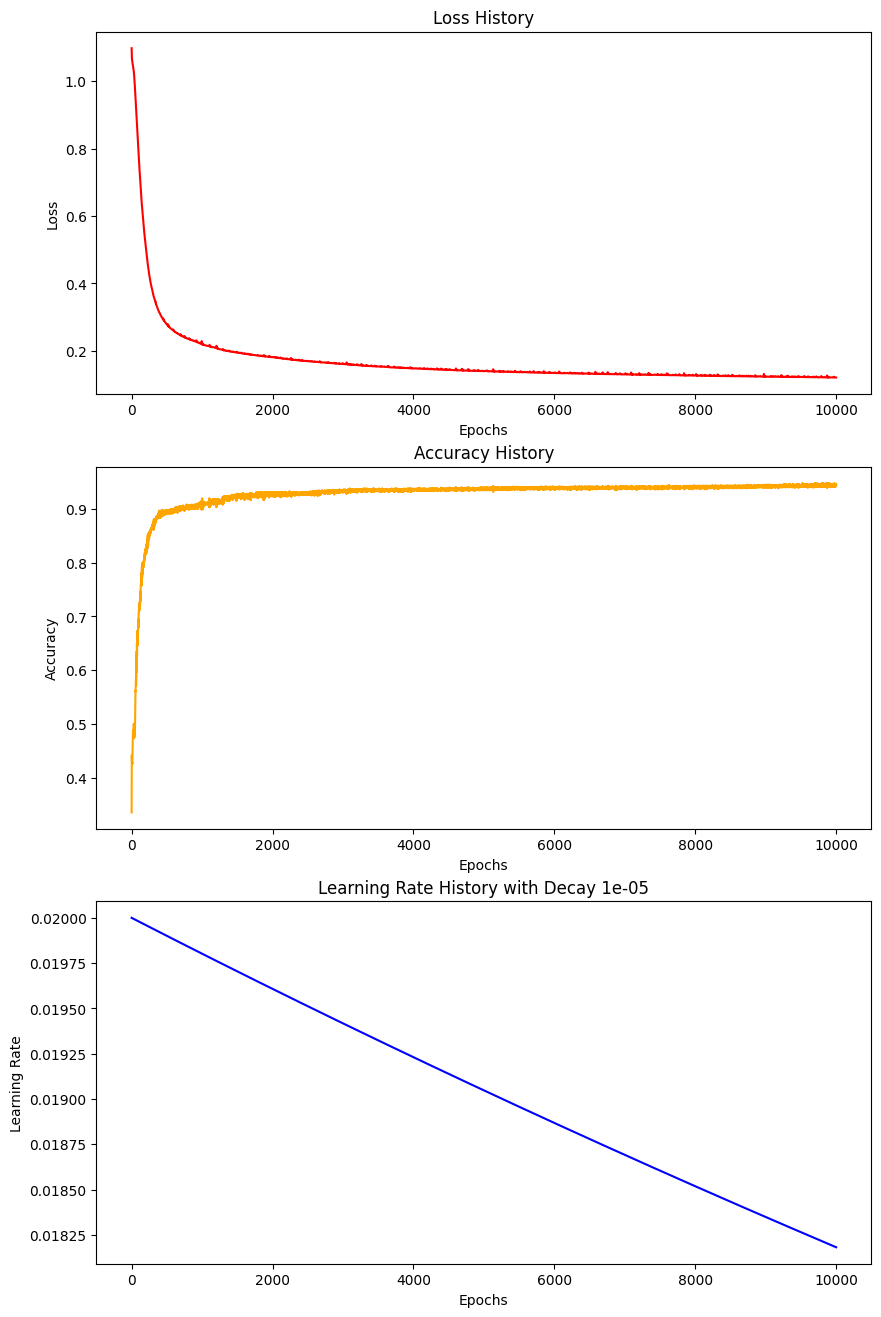

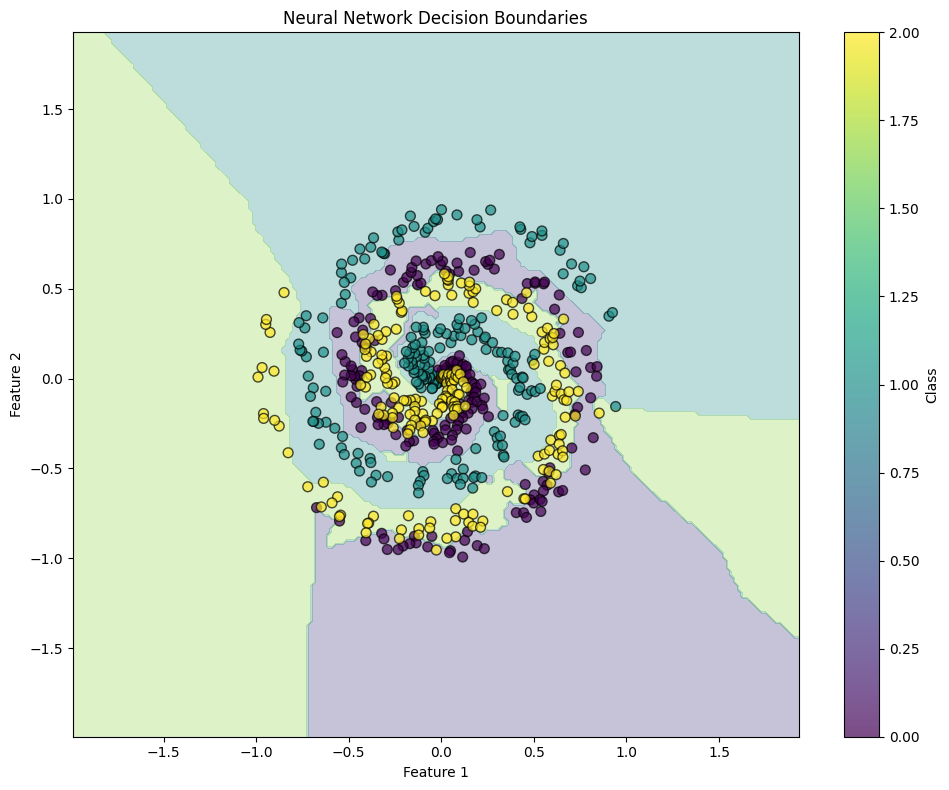

In [11]:
fig, axes = plt.subplots(nrows=3, figsize=(10, 16))

axes[0].set_title("Loss History")
axes[0].plot(loss_history, color="red")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")

axes[1].set_title("Accuracy History")
axes[1].plot(accuracy_history, color="orange")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")

axes[2].set_title(f"Learning Rate History with Decay {decay}")
axes[2].plot(learning_rate_history, color="blue")
axes[2].set_xlabel("Epochs")
axes[2].set_ylabel("Learning Rate")

print(f"Final Values: Loss {loss_history[-1]} Accuracy {accuracy_history[-1]} Learning Rate {learning_rate_history[-1]}")
print(f"Learning Rate {learning_rate} Decay {decay}")
plot_decision_boundary([dense1_layer, relu_activation, output_layer, loss_activation], X, y_true)
